In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# The Image Classification Dataset


One widely used benchmark for image classification is [MNIST](https://en.wikipedia.org/wiki/MNIST_database) [@LeCun.Bottou.Bengio.ea.1998], a dataset of 70,000 handwritten-digit images ($28 \times 28$ pixels, 10 classes). MNIST shaped a generation of machine learning research, but today even simple models exceed 95% accuracy (and a linear classifier already tops 90%), so differences between strong and weak models are hard to see. To compare models meaningfully we need a dataset where a linear baseline is clearly outpaced by a richer one.

We therefore use **Fashion-MNIST** [@Xiao.Rasul.Vollgraf.2017], a drop-in replacement released in 2017. It has exactly the same structure (60,000 training and 10,000 test images of $28 \times 28$ grayscale pixels, in 10 classes) but the classes are clothing categories (t-shirt, trouser, pullover, and so on) that are harder to tell apart, which makes accuracy differences between models clearly visible. For large-scale experiments the standard benchmark is ImageNet [@Deng.Dong.Socher.ea.2009] (1.2 million images, 1000 classes), but it is too large to keep our examples interactive; Fashion-MNIST teaches the same lessons at a fraction of the compute cost.

In [1]:
%matplotlib inline
import time
from d2l import torch as d2l
import torch
import torchvision
from torchvision import transforms

d2l.use_svg_display()

## Loading the Dataset

The library provides a preprocessed version of Fashion-MNIST that we can download and read into memory.

In [2]:
class FashionMNIST(d2l.DataModule):
    """The Fashion-MNIST dataset."""
    def __init__(self, batch_size=64, resize=(28, 28)):
        super().__init__()
        self.save_hyperparameters()
        trans = transforms.Compose([transforms.Resize(resize),
                                    transforms.ToTensor()])
        self.train = torchvision.datasets.FashionMNIST(
            root=self.root, train=True, transform=trans, download=True)
        self.val = torchvision.datasets.FashionMNIST(
            root=self.root, train=False, transform=trans, download=True)

Fashion-MNIST consists of images from 10 categories, each represented
by 6000 images in the training dataset and by 1000 in the test dataset.
A *test dataset* is used for evaluating model performance (it must not be used for training).
Consequently the training set and the test set
contain 60,000 and 10,000 images, respectively.

In [3]:
data = FashionMNIST(resize=(32, 32))
len(data.train), len(data.val)

(60000, 10000)

We instantiated the dataset with `resize=(32, 32)`, so each image is delivered as a single-channel tensor of spatial size $32 \times 32$. One subtlety matters here: where the channel axis lives. There are two conventions, *channel-first* $c \times h \times w$ ($c$ color channels, then height and width) and *channel-last* $h \times w \times c$. The `get_dataloader` method below produces the appropriate layout; we confirm the per-image shape once the loader is in place, below. Here $c = 1$ since the images are grayscale; most photographs have $c = 3$ channels (red, green, blue).


The categories of Fashion-MNIST have human-understandable names. 
The following convenience method converts between numeric labels and their names.

In [4]:
@d2l.add_to_class(FashionMNIST)
def text_labels(self, indices):
    """Return text labels."""
    labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
              'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [labels[int(i)] for i in indices]

## Reading a Minibatch

To make our life easier when reading from the training and test sets,
we use the built-in data iterator rather than creating one from scratch.
Recall that at each iteration, a data iterator
reads a minibatch of data with size `batch_size`.
We also randomly shuffle the examples for the training data iterator.

In [5]:
@d2l.add_to_class(FashionMNIST)
def get_dataloader(self, train):
    data = self.train if train else self.val
    return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train,
                                       num_workers=self.num_workers)

Now that the loader is defined, let us read one image and confirm where the channel axis lands.

In [6]:
X, y = next(iter(data.train_dataloader()))
X[0].shape  # channel-first: (channels, height, width)

torch.Size([1, 32, 32])

Here is the same batch again, now at batch granularity: the first axis is the batch dimension (64 images per step by default), followed by the per-image shape we just confirmed, and the labels arrive as a matching vector of 64 integers.

In [7]:
X, y = next(iter(data.train_dataloader()))
print(X.shape, X.dtype, y.shape, y.dtype)

torch.Size([64, 1, 32, 32]) torch.float32 torch.Size([64]) torch.int64


Let us time one full pass through the training set. A single pass takes seconds, not minutes; loading is not the bottleneck. For the convolutional networks of the coming chapters, a single forward and backward pass over a minibatch takes far longer than the corresponding I/O. (For the tiny linear models of *this* chapter the gap is much smaller; try the first exercise below.) If loading *were* slower than training, you would overlap I/O with compute via prefetching or raise the number of loader workers.

In [8]:
tic = time.time()
for X, y in data.train_dataloader():
    continue
f'{time.time() - tic:.2f} sec'

'2.27 sec'

## Visualization

We will often be using the Fashion-MNIST dataset. The `d2l` library provides a convenience function `show_images` that lays out a list of images in a grid with optional per-image titles.

Let's put it to good use. In general, it is a good idea to visualize and inspect data that you are training on. 
Humans are very good at spotting oddities, so visualization is a cheap safeguard against errors in the design of experiments. Here are the images and their corresponding labels (in text)
for the first few examples in the training dataset.

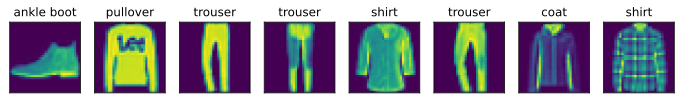

In [9]:
@d2l.add_to_class(FashionMNIST)
def visualize(self, batch, nrows=1, ncols=8, labels=None):
    X, y = batch
    if not labels:
        labels = self.text_labels(y)
    d2l.show_images(X.squeeze(1), nrows, ncols, titles=labels)
batch = next(iter(data.val_dataloader()))
data.visualize(batch)

We are now ready to work with the Fashion-MNIST dataset in the sections that follow.

## Summary

We now have a slightly more realistic dataset to use for classification. Fashion-MNIST is an apparel classification dataset consisting of images representing 10 categories. We will use this dataset in subsequent sections and chapters to evaluate various network designs, from a simple linear model to advanced residual networks. As we commonly do with images, we read them as a tensor of shape (batch size, number of channels, height, width). For now, we only have one channel as the images are grayscale (the visualization above uses a false color palette for improved visibility). A well-implemented data iterator keeps loading fast, so that training speed is set by the model rather than by I/O.


## Exercises

1. Time one full training epoch at `batch_size` of 1, 16, 64, 256, and 1024. Plot throughput (images per second) against `batch_size`. Why does throughput rise with batch size up to a point and then plateau?
1. Set `num_workers=0` (single-threaded loading) and compare against the default multi-worker setting. Under what conditions does increasing `num_workers` stop helping?
1. PyTorch stores tensors in channel-first order $(c, h, w)$, while TensorFlow and JAX use channel-last $(h, w, c)$. Read the `get_dataloader` implementations for all four frameworks. Which step introduces the channel dimension, and where does the layout differ?

[Discussions](https://d2l.discourse.group/t/49)